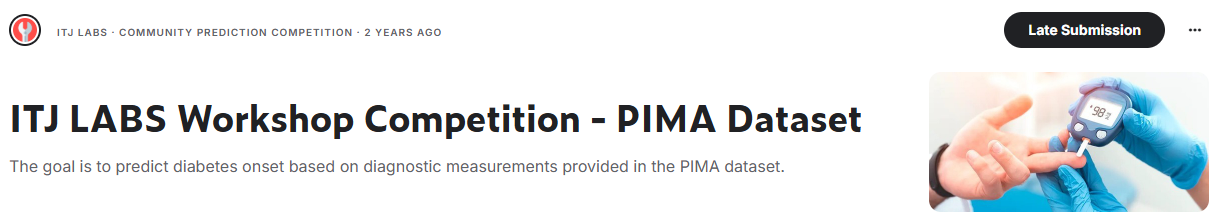

* https://www.kaggle.com/competitions/itj-labs-workshop-competition-pima-dataset

<pre>
glucose        : 공복 후 측정한 혈당이 126 mg/dL 이상                        : 126
bloodpressure  : 고혈압은 수축기 혈압이 140mmHg 이상,확장기 혈압이 90mmHg 이상 : 90
skinthickness  : 12.72 ± 7.39                                               : 20
insulin        : 2.6~24.9(uU/mL)   2시간 후 22~79(uU/mL)                    : 25 ~
bmi            : 25kg/m² 이상부터 비만                                      : 30
diabet         : 유전력의크기???
age            : 고령 산모(35세 이상)
pregnancies    : 다태 임신                                                  : 4~5

In [1]:
from sklearn import set_config
set_config(display="text")          #인코딩 텍스트로 바꿔달라는

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')


#----------차트 속성 (한글처리/그리드)
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False



#----------문제/답 분리
from sklearn.model_selection import train_test_split 


#----------분류모델
from sklearn.linear_model import LogisticRegression   #선형모델 
from sklearn.ensemble import RandomForestClassifier   #트리모델

#----------모델결합(Ensembles)
from sklearn.ensemble import VotingClassifier, VotingRegressor   #앙상블


#----------평가 매트릭스
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report


#----------교차검증
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, cross_validate


#----------인코딩(글자->숫자)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


#----------정규화(스케일링)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler 


#----------차원 축소
from sklearn.decomposition import PCA 

# **[1] Data Load**
* target : outcome

In [3]:
train = pd.read_csv("../../Datas/#pima/train.csv") 
test = pd.read_csv("../../Datas/#pima/test.csv")

In [4]:
train.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,90,60,0,0,23.5,0.191,25,0
1,2,92,52,0,0,30.1,0.141,22,0


## **데이터 수정**

### 컬럼 소문자 변경

In [5]:
train.columns = train.columns.str.lower()
test.columns = test.columns.str.lower()

### 컬럼 이름 변경

In [6]:
train = train.rename(columns={'bloodpressure':'blood',
                              'skinthickness' : 'skin',
                              'diabetespedigreefunction': 'diabet'})

test = test.rename(columns={'bloodpressure':'blood',
                              'skinthickness' : 'skin',
                              'diabetespedigreefunction': 'diabet'})

In [7]:
train.head(2)

,pregnancies,glucose,blood,skin,insulin,bmi,diabet,age,outcome
0,2,90,60,0,0,23.5,0.191,25,0
1,2,92,52,0,0,30.1,0.141,22,0


In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pregnancies  616 non-null    int64  
 1   glucose      616 non-null    int64  
 2   blood        616 non-null    int64  
 3   skin         616 non-null    int64  
 4   insulin      616 non-null    int64  
 5   bmi          616 non-null    float64
 6   diabet       616 non-null    float64
 7   age          616 non-null    int64  
 8   outcome      616 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 43.4 KB


* <font color='red'> 결측 없음, 글자 없음

# **[2] 공통함수**

In [9]:
def myscore(X_train7, y_train7, X_test3, y_test3, model=None) :
    if model is None : 
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    
    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)

    acc = accuracy_score(y_test3, pred)
    print( f"acc : {acc:.4f}" )

In [10]:
def myscore222(df,  model=None, MY_TARGET="outcome") :
    X = df.drop(columns=['outcome'])
    y = df[MY_TARGET]
    X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, random_state=1234, shuffle=True)

    if model is None : 
        #LogisticRegression , RandomForestClassifier
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    

    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)

    #-------------------------------------------------pred
    acc       = accuracy_score(y_test3, pred)
    f1        = f1_score(y_test3, pred)
    precision = precision_score(y_test3, pred)
    recall    = recall_score(y_test3, pred)    
    print( f"acc : {acc:.4f}  f1 : {f1:.4f}  precision : {precision:.4f}  recall : {recall:.4f}" )
    
    cm = confusion_matrix(y_test3, pred)
    print( cm )
    
    #-------------------------------------------------proba
    # proba = model.predict_proba(X_test3)
    # proba_p = proba[:,1]
    #print(proba_p)
    
    # precision, recall, th = precision_recall_curve(y_test3, proba_p)
    # #print(precision, recall, th)
    # #print(len(precision), len(recall), len(th))

    # plt.figure(figsize=(8,2))
    # plt.plot(th, precision[:len(th)], label="precision")
    # plt.plot(th, recall[:len(th)], label="recall")
    # plt.legend()
    # plt.title("precision_reacall_curv")
    # plt.show()

    #-------------------------------------------------proba : roc
    # roc = roc_auc_score(y_test3, proba_p)
    # print( f"roc auc score : {roc:.4f}" )
    # fpr, tpr, th = roc_curve(y_test3, proba_p)

    # plt.figure(figsize=(8,2))
    # plt.plot(fpr, tpr)
    # plt.plot([0, 1], [0, 1], 'k--')
    # plt.title("roc_curve")
    # plt.xlabel("False Positive Rate (FPR)")
    # plt.ylabel("True Positive Rate (TPR) == recall")
    # plt.show()       
    
    return model

# <font color=darkorange> **※1차 점수※**
* f1 : 0.5872

In [11]:
res = myscore222(train)

RandomForestClassifier
acc : 0.7568  f1 : 0.5872  precision : 0.7111  recall : 0.5000
[[108  13]
 [ 32  32]]


# **[3] EDA(Exploratory Data Analysis)**

## **시각화 hist()**
* 데이터 분포도 확인(왜도, 첨도, 정규분포)

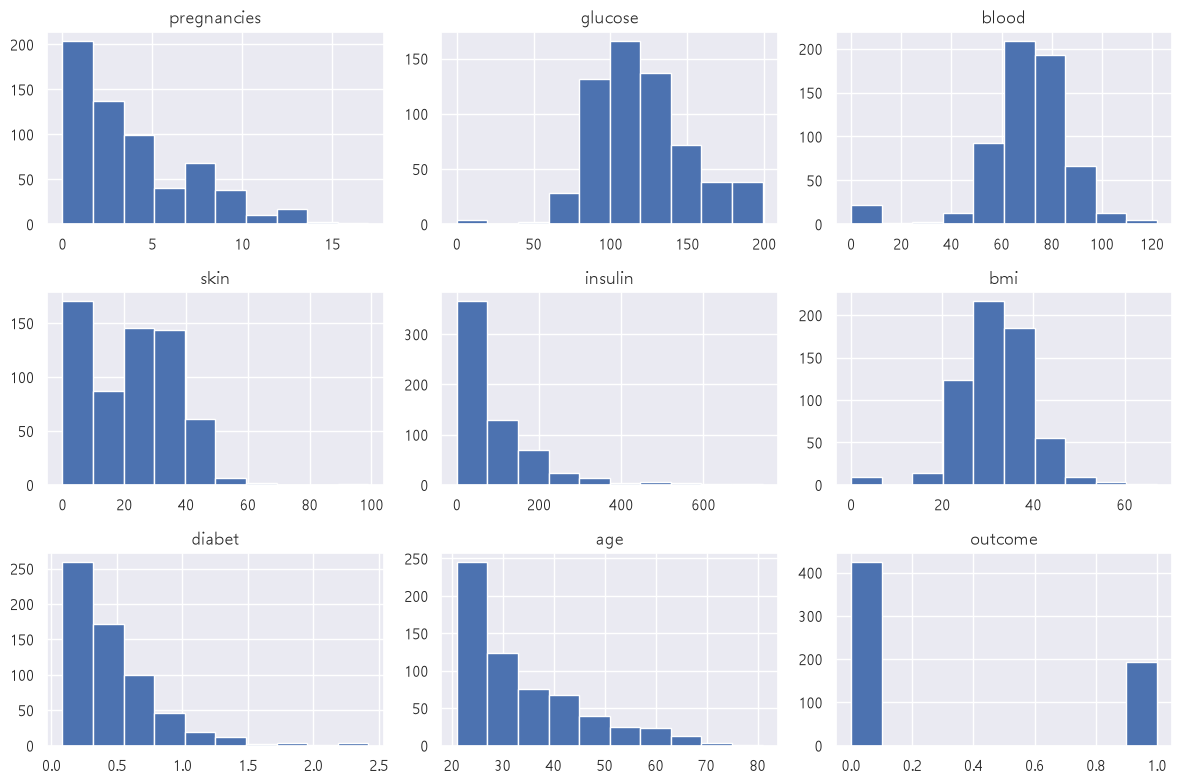

In [12]:
train.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

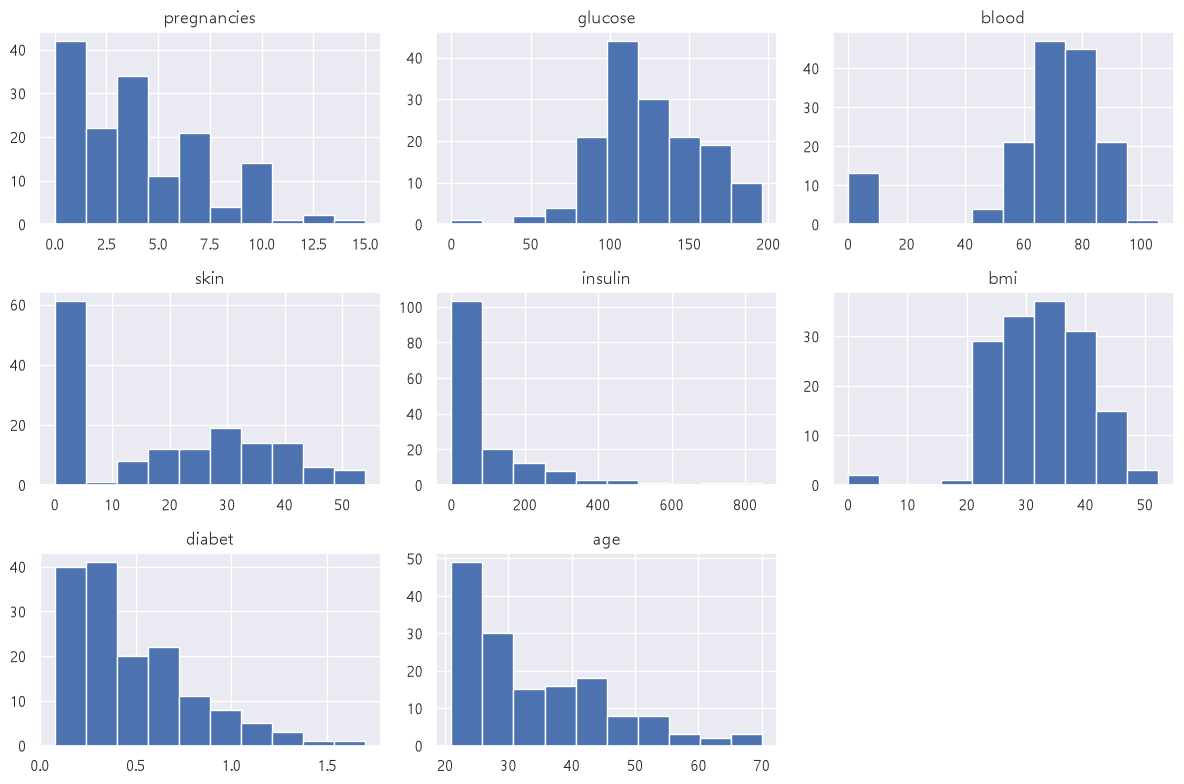

In [13]:
test.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

## **타겟분포도 : outcome**

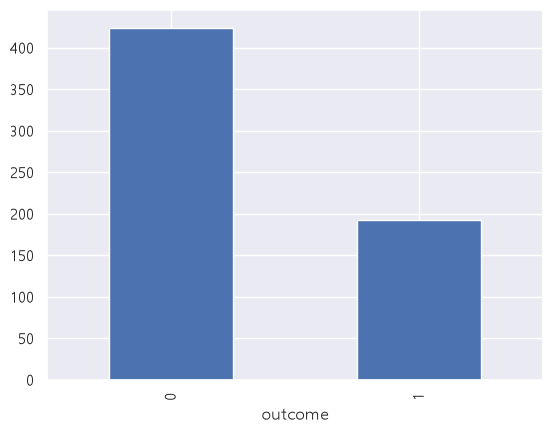

In [14]:
train['outcome'].value_counts().plot.bar()
plt.show()

## **결측여부**

In [15]:
train.isna().sum()

pregnancies    0
glucose        0
blood          0
skin           0
insulin        0
bmi            0
diabet         0
age            0
outcome        0
dtype: int64

## **(1) 이상치 : 0 데이터**
* glucose, blood, skin, insulin, bmi
* diabet : 0.078~0.24 정상범위
* <font color=red> <b> test에는 outcome이 없다 --> 컬럼별 평균으로 채워야 함 (원본적용까지 아래 다 무시)

### 컬럼별 정상/비정상 구분

In [16]:
for col in train.columns :
    cnt = train[train[col]==0][col].count()
    print(f"{col}\t{cnt}")

pregnancies	92
glucose	4
blood	22
skin	166
insulin	285
bmi	9
diabet	0
age	0
outcome	424


In [17]:
train.head(2)

,pregnancies,glucose,blood,skin,insulin,bmi,diabet,age,outcome
0,2,90,60,0,0,23.5,0.191,25,0
1,2,92,52,0,0,30.1,0.141,22,0


### 0을 평균값으로 채우기

In [18]:
mean0 = train[(train['outcome'] == 0) & (train['glucose'] != 0)]['glucose'].mean()
mean1 = train[(train['outcome'] == 1) & (train['glucose'] != 0)]['glucose'].mean()
print(mean0, mean1)

110.58194774346794 143.60732984293193


* 0을 NaN으로 변경 후

In [19]:
for col in ['glucose', 'blood', 'skin', 'insulin', 'bmi'] :
    train[col] = train[col].replace(0, np.nan)

In [20]:
traincp = train.copy()

In [21]:
traincp['blood'].isna().sum()

np.int64(22)

In [22]:
traincp.groupby('outcome')['blood'].mean()

outcome
0    70.788835
1    74.994505
Name: blood, dtype: float64

In [23]:
print ( traincp[traincp['outcome']==0]['blood'].mean() )
print ( traincp[traincp['outcome']==1]['blood'].mean() )

70.78883495145631
74.99450549450549


In [24]:
traincp.groupby('outcome')['blood'].mean()

outcome
0    70.788835
1    74.994505
Name: blood, dtype: float64

* 방법1) train.loc[줄(조건절), 칸] = value
* <font color=blue> <b> 그냥 이거 쓰자

In [25]:
traincp.loc[(train['outcome']==0) & (train['blood']>0),['blood']]  = mean0
traincp.loc[(train['outcome']==1) & (train['blood']>0),['blood']]  = mean1

* 방법2) fillna()

In [26]:
traincp = train.copy()

In [27]:
traincp.groupby('outcome')['blood'].mean()

outcome
0    70.788835
1    74.994505
Name: blood, dtype: float64

In [28]:
for col in ['glucose', 'blood', 'skin', 'insulin', 'bmi', 'diabet'] :
    traincp[col] = traincp[col].fillna(traincp.groupby('outcome')[col].transform('mean'))

In [29]:
traincp.isna().sum()

pregnancies    0
glucose        0
blood          0
skin           0
insulin        0
bmi            0
diabet         0
age            0
outcome        0
dtype: int64

### <font color=blue>**원본적용**

In [30]:
train['blood'].mean()

np.float64(72.07744107744108)

In [31]:
for col in ['glucose' , 'blood' , 'skin' , 'insulin', 'bmi'] : 
    train[col] = train[col].replace( 0,  np.nan)
    test[col] = test[col].replace( 0,  np.nan)

    #train은 outcome 평균으로 채우기
    train[col] = train[col].fillna( train.groupby('outcome')[col].transform('mean') )

    # test는 train의 outcome별 평균들을 평균내서 채우기 (test엔 outcome이 없으므로)
    test[col] = test[col].fillna( train.groupby('outcome')[col].transform('mean') )

# <font color=darkorange> **※2차 점수※**
* f1 : 0.5872
* f1 : 0.7769

In [32]:
res = myscore222(train)

RandomForestClassifier
acc : 0.8541  f1 : 0.7769  precision : 0.8246  recall : 0.7344
[[111  10]
 [ 17  47]]


## **(2) 이상치 : outlier**

<pre>
glucose        : 공복 후 측정한 혈당이 126 mg/dL 이상                        : 126
bloodpressure  : 고혈압은 수축기 혈압이 140mmHg 이상,확장기 혈압이 90mmHg 이상 : 90
skinthickness  : 12.72 ± 7.39                                               : 20
insulin        : 2.6~24.9(uU/mL)   2시간 후 22~79(uU/mL)                    : 25 ~
bmi            : 25kg/m² 이상부터 비만                                      : 30
diabet         : 유전력의크기???
pregnancies    : 다태 임신                                                  : 4~5

### hist()

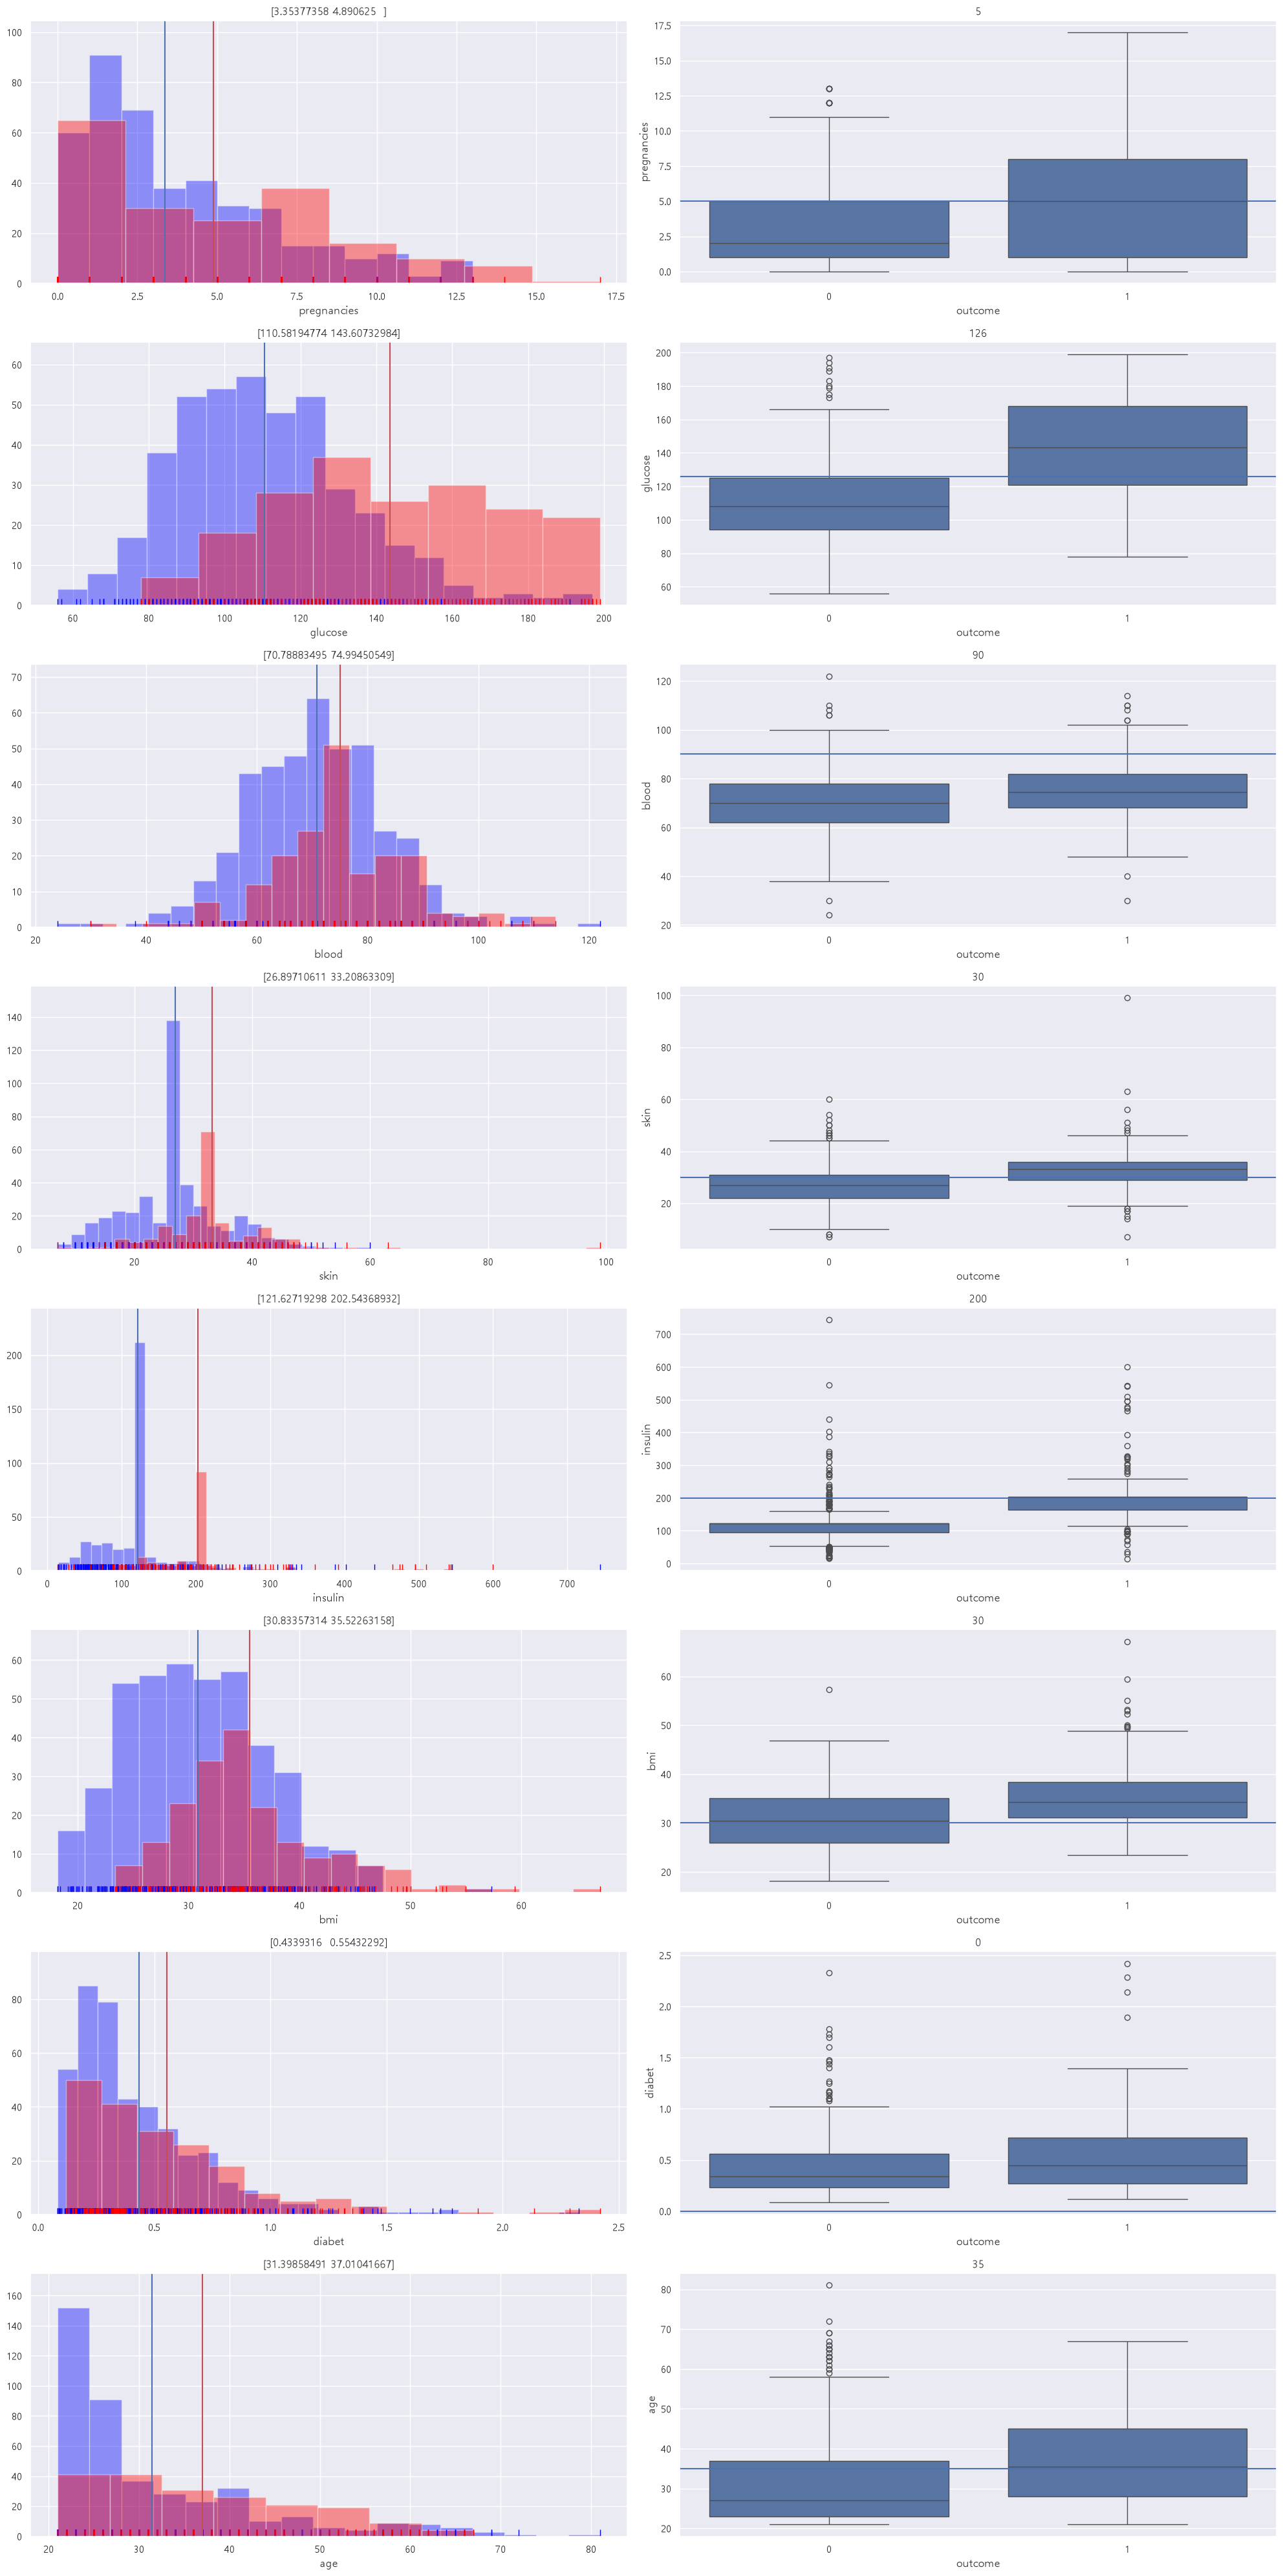

In [33]:
cols = ['pregnancies', 'glucose', 'blood', 'skin', 'insulin', 'bmi', 'diabet', 'age']
fig, axes = plt.subplots(nrows=len(cols), ncols=2, figsize=(20, 40))
nomal_val = [5, 126, 90,30, 200, 30, 0, 35]

for i in range(len(cols)):
    col = cols[i]
    sns.distplot(train[train['outcome']==0][col]   , kde=False, rug=True, color="blue", fit_kws={"color":"#E48E58"},label="정상"  ,ax=axes[i][0])
    sns.distplot(train[train['outcome']==1][col]   , kde=False, rug=True, color="red", fit_kws={"color":"#3333FF"},label="당뇨"  ,ax=axes[i][0])
    axes[i][0].axvline(train.groupby('outcome')[col].mean().values[0], color='b')
    axes[i][0].axvline(train.groupby('outcome')[col].mean().values[1], color='r')
    axes[i][0].set_title(f"{train.groupby('outcome')[col].mean().values}")

    sns.boxplot(x="outcome",     y=col, data=train,  ax=axes[i][1])
    axes[i][1].axhline(nomal_val[i], color='b')
    axes[i][1].set_title(f"{nomal_val[i]}")

plt.tight_layout()
plt.show()
plt.close()

### 상관분석

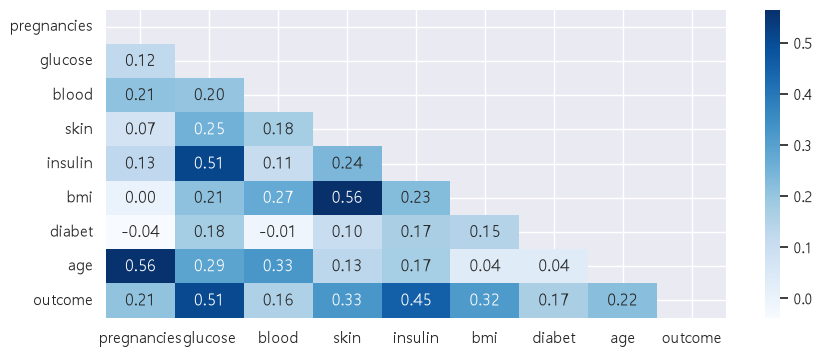

In [34]:
plt.figure(figsize=(10, 4))

# 반쪽으로 보기
mask = np.triu(np.ones_like(train.corr(), dtype=bool))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="Blues", mask=mask)    #.2f = 소수점 2자리까지~ (d=숫자로)
plt.show()
# test에는 타겟피쳐가 없기 때문에 train만 봐도 됨

* glucose, insulin

#### glucose

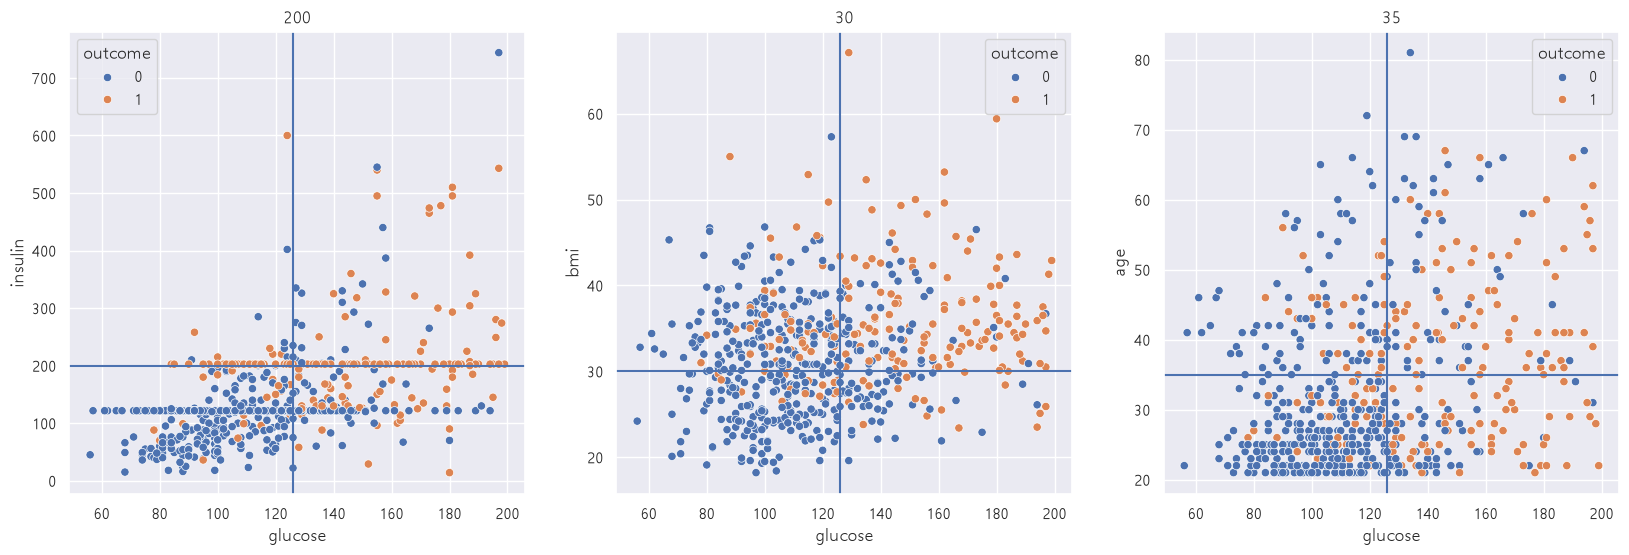

In [35]:
#cols = ['pregnancies', 'glucose', 'blood', 'skin', 'insulin', 'bmi', 'diabet', 'age']
nomal_val = [5, 126, 90,30, 200, 30, 0, 35]

sub_cols = ["insulin", "bmi", "age"]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

sns.scatterplot(x="glucose", y=sub_cols[0], data=train, hue="outcome",ax=axes[0])
axes[0].axvline(nomal_val[1], color='b')   #----glucose
axes[0].axhline(nomal_val[4], color='b')   #----insulin
axes[0].set_title(f"{nomal_val[4]}")

sns.scatterplot(x="glucose", y=sub_cols[1], data=train, hue="outcome",ax=axes[1])
axes[1].axvline(nomal_val[1], color='b')   #----glucose
axes[1].axhline(nomal_val[5], color='b')   #----bmi
axes[1].set_title(f"{nomal_val[5]}")

sns.scatterplot(x="glucose", y=sub_cols[2], data=train, hue="outcome",ax=axes[2])
axes[2].axvline(nomal_val[1], color='b')   #----glucose
axes[2].axhline(nomal_val[7], color='b')   #----age
axes[2].set_title(f"{nomal_val[7]}")

plt.show()

#### bmi

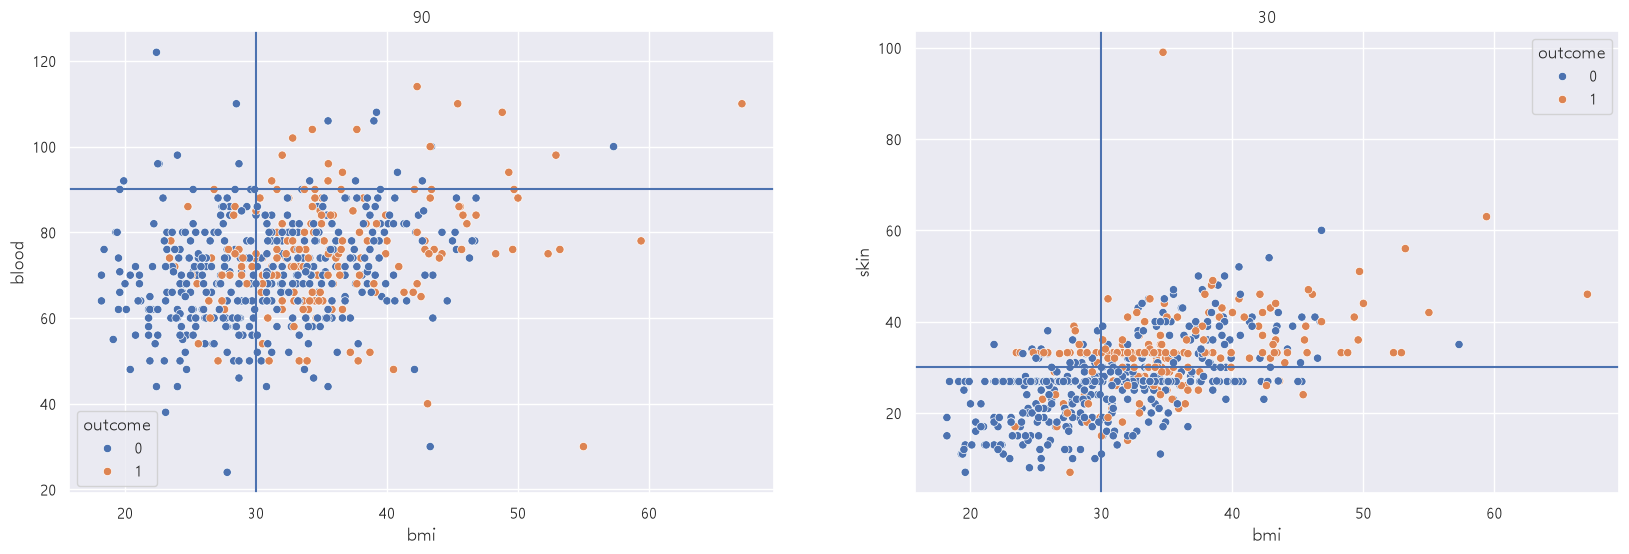

In [36]:
sub_cols = ["blood","skin"]
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

sns.scatterplot(x="bmi", y=sub_cols[0], data=train, hue="outcome",ax=axes[0])
axes[0].axvline(nomal_val[5], color='b')
axes[0].axhline(nomal_val[2], color='b')
axes[0].set_title(f"{nomal_val[2]}")

sns.scatterplot(x="bmi", y=sub_cols[1], data=train, hue="outcome",ax=axes[1])
axes[1].axvline(nomal_val[5], color='b')
axes[1].axhline(nomal_val[3], color='b')
axes[1].set_title(f"{nomal_val[3]}")

plt.show()

#### age

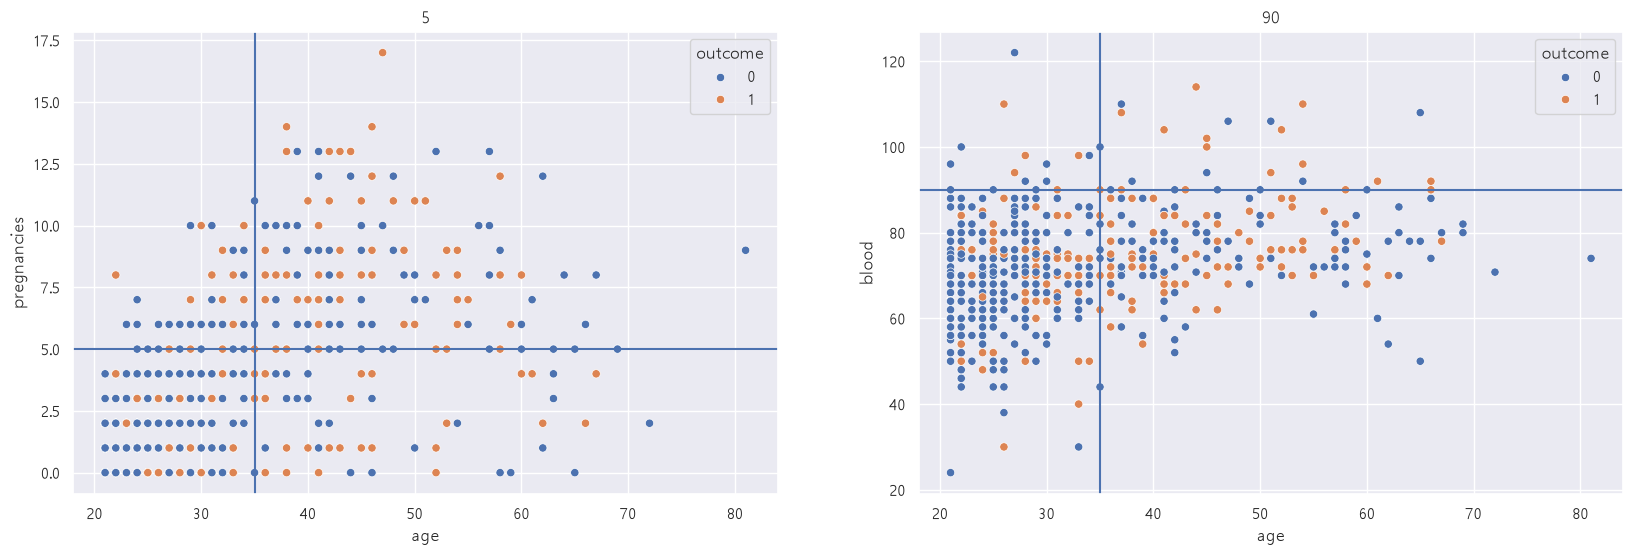

In [37]:
sub_cols = ["pregnancies","blood"]
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

sns.scatterplot(x="age", y=sub_cols[0], data=train, hue="outcome",ax=axes[0])
axes[0].axvline(nomal_val[7], color='b')
axes[0].axhline(nomal_val[0], color='b')
axes[0].set_title(f"{nomal_val[0]}")

sns.scatterplot(x="age", y=sub_cols[1], data=train, hue="outcome",ax=axes[1])
axes[1].axvline(nomal_val[7], color='b')
axes[1].axhline(nomal_val[2], color='b')
axes[1].set_title(f"{nomal_val[2]}")

plt.show()

In [38]:
train.describe()

,pregnancies,glucose,blood,skin,insulin,bmi,diabet,age,outcome
count,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000
mean,3.832792,120.875573,72.099693,28.864335,146.847919,32.295098,0.471456,33.147727,0.311688
std,3.406302,30.203676,12.519718,8.995946,82.588534,6.856495,0.335874,11.775236,0.463560
min,0.000000,56.000000,24.000000,7.000000,14.000000,18.200000,0.084000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,25.000000,115.000000,27.575000,0.245000,24.000000,0.000000
50%,3.000000,116.500000,72.000000,27.000000,121.627193,32.000000,0.372500,29.000000,0.000000
75%,6.000000,139.000000,80.000000,33.208633,200.000000,35.925000,0.607750,40.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,744.000000,67.100000,2.420000,81.000000,1.000000


# <font color=darkorange> **※outlier 제거 후 점수※**

In [39]:
del_idx_list = []

## **pregnancies >= 15**
* f1 : 0.5872
* f1 : 0.7769
* f1 : 0.7414

In [40]:
traincp = train.copy()
idx_list = traincp[traincp['pregnancies'] >= 15].index
del_idx_list.extend(idx_list)
print(del_idx_list)
traincp = traincp.drop( del_idx_list )
myscore222(traincp)

[484]
RandomForestClassifier
acc : 0.8378  f1 : 0.7414  precision : 0.8113  recall : 0.6825
[[112  10]
 [ 20  43]]


RandomForestClassifier(random_state=1234)

## **skin >= 90**
* f1 : 0.5872
* f1 : 0.7769
* f1 : 0.7350

In [41]:
traincp = train.copy()
idx_list = traincp[traincp['skin'] >= 90].index
del_idx_list.extend(idx_list)
print(del_idx_list)
traincp = traincp.drop( del_idx_list )
myscore222(traincp)

[484, 234]
RandomForestClassifier
acc : 0.8324  f1 : 0.7350  precision : 0.7679  recall : 0.7049
[[111  13]
 [ 18  43]]


RandomForestClassifier(random_state=1234)

## **insulin >= 700**
* f1 : 0.5872
* f1 : 0.7769
* f1 : 0.7611

In [42]:
traincp = train.copy()
idx_list = traincp[traincp['insulin'] >= 700].index
del_idx_list.extend(idx_list)
print(del_idx_list)
traincp = traincp.drop( del_idx_list )
myscore222(traincp)

[484, 234, 236]
RandomForestClassifier
acc : 0.8533  f1 : 0.7611  precision : 0.7963  recall : 0.7288
[[114  11]
 [ 16  43]]


RandomForestClassifier(random_state=1234)

## **bmi >= 60**
* f1 : 0.5872
* f1 : 0.7769
* f1 : 0.7500

In [43]:
traincp = train.copy()
idx_list = traincp[traincp['bmi'] >= 60].index
del_idx_list.extend(idx_list)
print(del_idx_list)
traincp = traincp.drop( del_idx_list )
myscore222(traincp)

[484, 234, 236, 80]
RandomForestClassifier
acc : 0.8587  f1 : 0.7500  precision : 0.8478  recall : 0.6724
[[119   7]
 [ 19  39]]


RandomForestClassifier(random_state=1234)

## <font color=blue> **원본적용**

In [44]:
train = train.drop(del_idx_list)
model = myscore222(train)

RandomForestClassifier
acc : 0.8587  f1 : 0.7500  precision : 0.8478  recall : 0.6724
[[119   7]
 [ 19  39]]


# <font color=darkorange> **※3차 점수※**

In [45]:
pred = model.predict(test)
sub = pd.DataFrame({
    'ID': test.index,       
    'Outcome': pred
})
sub.to_csv('lec13_sub_v01.csv', index=False)

# **[4] 교차검증**

In [46]:
X = train.drop(columns=['outcome'])
y = train['outcome']
model = RandomForestClassifier(n_estimators=100, random_state=1234)
myparam = {"n_estimators"     :[100, 200,300],
           "min_samples_split":[2, 3, 4],
           "min_samples_leaf" :[1, 2, 3]
          }

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)
gcv_model = GridSearchCV(model, param_grid=myparam, scoring="f1", refit=True, cv=kf)
gcv_model.fit(X, y)

print(gcv_model.best_params_)
print(gcv_model.best_score_)

{'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}
0.8001679528860987


# <font color=darkorange> **※4차 점수※**

In [47]:
pred = gcv_model.predict(test)
sub = pd.DataFrame({
    'ID': test.index,       
    'Outcome': pred
})
sub.to_csv('lec13_sub_v02.csv', index=False)

# **[5] 앙상블**

## 튜닝 1차

In [48]:
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

model1 = GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=1212, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)
model2 = LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=1212, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0, verbose=-1)
model3 = RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       n_estimators=100, n_jobs=-1, oob_score=False,
                       random_state=1212, verbose=0, warm_start=False)

In [49]:
vt_model = VotingClassifier(
    estimators=[
        ("gb"  , model1),
        ("lgbm"  , model2),
        ("rf" , model3)
    ],
    voting="hard"  #soft
)
model = myscore222(train, model=vt_model)

VotingClassifier
acc : 0.8804  f1 : 0.7925  precision : 0.8750  recall : 0.7241
[[120   6]
 [ 16  42]]


In [50]:
pred = model.predict(test)
sub = pd.DataFrame({
    'ID': test.index,       
    'Outcome': pred
})
sub.to_csv('lec13_sub_v03.csv', index=False)

## 튜닝 2차

In [51]:
rf = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=3, min_samples_leaf=1)
model = myscore222(traincp, model=rf)

RandomForestClassifier
acc : 0.8641  f1 : 0.7619  precision : 0.8511  recall : 0.6897
[[119   7]
 [ 18  40]]


In [52]:
pred = model.predict(test)
sub = pd.DataFrame({
    'ID': test.index,       
    'Outcome': pred
})
sub.to_csv('lec13_sub_v04.csv', index=False)

# **[임계치 강제 조정]**
* Binarizer : Threshold를 OO으로 잡고, 보다크면 1로 이하는 0으로 바꿈

In [53]:
from sklearn.preprocessing import Binarizer

In [54]:
X = train.drop(columns=['outcome'])
y = train['outcome']
X_train7, X_test3, y_train7, y_test3 = train_test_split( X, y, test_size=0.2, random_state=1234, shuffle=True)

model = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=3, min_samples_leaf=1)
model.fit(X_train7, y_train7)
pred = model.predict(X_test3)

#-------------------------------------------------pred
acc       = accuracy_score(y_test3, pred)
f1        = f1_score(y_test3, pred)
precision = precision_score(y_test3, pred)
recall    = recall_score(y_test3, pred)    
print( f"acc : {acc:.4f}  f1 : {f1:.4f}  precision : {precision:.4f}  recall : {recall:.4f}" )

cm = confusion_matrix(y_test3, pred)
print( cm )

#-------------------------------------------------proba
proba = model.predict_proba(X_test3)
proba_p = proba[:,1]


acc : 0.8699  f1 : 0.7714  precision : 0.8182  recall : 0.7297
[[80  6]
 [10 27]]


In [55]:
for th in [0.5, 0.49, 0.48, 0.47, 0.46, 0.45, 0.44] :
    bz = Binarizer(threshold=th)
    bz.fit(proba_p.reshape(-1, 1) )
    pred = bz.transform(proba_p.reshape(-1, 1) )
    
    #-------------------------------------------------pred
    acc       = accuracy_score(y_test3, pred)
    f1        = f1_score(y_test3, pred)
    print( f"acc : {acc:.4f}  f1 : {f1:.4f}" )
    
    cm = confusion_matrix(y_test3, pred)
    print( cm )

acc : 0.8699  f1 : 0.7714
[[80  6]
 [10 27]]
acc : 0.8699  f1 : 0.7714
[[80  6]
 [10 27]]
acc : 0.8780  f1 : 0.7887
[[80  6]
 [ 9 28]]
acc : 0.8780  f1 : 0.7887
[[80  6]
 [ 9 28]]
acc : 0.8780  f1 : 0.7945
[[79  7]
 [ 8 29]]
acc : 0.8780  f1 : 0.7945
[[79  7]
 [ 8 29]]
acc : 0.8862  f1 : 0.8108
[[79  7]
 [ 7 30]]


# <font color=darkorange> **※최종 점수※**

In [56]:
proba = model.predict_proba(test)
proba_p = proba[:,1]

bz = Binarizer(threshold=0.45)
bz.fit(proba_p.reshape(-1, 1) )
pred = bz.transform(proba_p.reshape(-1, 1) )

In [57]:
pred = pred.reshape(-1)
pred[:10]

array([0., 0., 1., 1., 0., 0., 0., 1., 0., 0.])

In [58]:
sub = pd.DataFrame({
    'ID': test.index,       
    'Outcome': pred
})
sub.to_csv('lec13_sub_v05.csv', index=False)